<a href="https://colab.research.google.com/github/kjahan/graph_embeddings/blob/main/notebooks/imdb_graph_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyze IMDB Dataset

https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset

Download the IMDB data (archive.zip) from Kaggle and manually upload in `data` folder!

In [6]:
!mkdir -p data/imdb

In [24]:
#!jar xvf data/archive.zip
!unzip data/archive.zip -d data/imdb

Archive:  data/archive.zip
  inflating: data/imdb/credits.csv   
  inflating: data/imdb/keywords.csv  
  inflating: data/imdb/links.csv     
  inflating: data/imdb/links_small.csv  
  inflating: data/imdb/movies_metadata.csv  
  inflating: data/imdb/ratings.csv   
  inflating: data/imdb/ratings_small.csv  


## Imports

In [1]:
import pandas as pd
import numpy as np

import json
from collections import deque
import re

## Utilities

https://github.com/kjahan/bacon_number/

In [25]:
def process(base_folder, movies_metadata_fn, credits_fn):
    # Process movies_metadata data structure/schema
    metadata = pd.read_csv(base_folder + movies_metadata_fn)
    # Cast id to int64 and drop any NAN values!
    metadata.id = pd.to_numeric(metadata.id, downcast='signed', errors='coerce')
    metadata = metadata[metadata['id'].notna()]
    # cast id to int64 for later join
    metadata['id'] = metadata['id'].astype(np.int64)
    # Process credits data structure/schema
    credits = pd.read_csv(base_folder + credits_fn)
    # Cast id to int
    credits.id = pd.to_numeric(credits.id, downcast='signed', errors='coerce')
    # cast id to int64 for later join
    credits['id'] = credits['id'].astype(np.int64)
    # let's grab movies ids from both datasets (movies metadata and credits) and union them
    credits_id_set = set(credits['id'].tolist())
    metadata_id_set = set(metadata['id'].tolist())
    union = credits_id_set.union(metadata_id_set)
    # since movie/actors ids might overlap let's map movie ids to
    # a new space using random to reduce the collision chance!
    mapped_ids = {x : x + np.random.randint(1, 1e10) for x in union}
    # apply the mapping
    metadata['id'] = metadata['id'].apply(lambda x: mapped_ids[x])
    credits['id'] = credits['id'].apply(lambda x: mapped_ids[x])
    # test again for collision detetcion
    credits_id_set = set(credits['id'].tolist())
    metadata_id_set = set(metadata['id'].tolist())
    # Let's test Salmna Khan (actor id=42802) and raise excetion if that id is in movies data
    salman_khan_id = 42802
    salman_khan_id_exists = (salman_khan_id in credits_id_set) or (salman_khan_id in metadata_id_set)
    new_movie_id = mapped_ids[salman_khan_id]
    salman_khan_mapped_id_exists = (new_movie_id in credits_id_set) or (new_movie_id in metadata_id_set)
    if salman_khan_id_exists or not salman_khan_mapped_id_exists:
        print("Mapping movie ids failed - collision for Salman Khan actor id with a movie id!")
        raise RuntimeError
    # Let's join the two dataset based on movie id
    merged = pd.merge(metadata, credits, on='id')
    return merged

In [26]:
def cleanup_json(dirty_json):
    b = re.sub("{'", '{"', dirty_json)
    c = re.sub("':", '":', b)
    d = re.sub(", '", ', "', c)
    e = re.sub(": '", ': "', d)
    f = re.sub("', ", '", ', e)
    h = re.sub("'", '', f)
    i = re.sub('}', '"}', h)
    j = re.sub(r': ([a-zA-Z\s]+), ', r': "\1", ', i)
    k = re.sub(r' None"', r' null', j)
    return k

## Construct IMDB Graph

In [27]:
class MovieActorGraph:
    def __init__(self):
        # a map from movie id to a list of actor id's
        self.movie_actor_adj_list = {}
        # a map from actor id to a list of movie id's
        self.actor_movie_adj_list = {}
        # a map from movies id to their title
        self.movies_map = {}
        # a map from movies titles to their ids
        self.inv_movies_map = {}
        # a map from actors id to their name
        self.actors_map = {}
        # a map from actors names to their ids
        self.inv_actors_map = {}

    def construc_inverse_maps(self):
        self.inv_actors_map = {v: k for k, v in self.actors_map.items()}
        self.inv_movies_map = {v: k for k, v in self.movies_map.items()}

    def construct_graph(self, raw_data):
        cnt, errors = 0, 0
        failed_movies = {}
        for index, row in raw_data.iterrows():
            cnt += 1
            movie_id, movie_title = row['id'], row['title']
            if movie_id not in self.movies_map:
                self.movies_map[movie_id] = movie_title
            dirty_json = row['cast']
            try:
                dirty_json = cleanup_json(dirty_json)
                cast_data = json.loads(dirty_json)
                for cast in cast_data:
                    actor_name = cast['name']
                    actor_id = cast['id']
                    if actor_id not in self.actors_map:
                        self.actors_map[actor_id] = actor_name
                    # build movie-actor adj list
                    if movie_id not in self.movie_actor_adj_list:
                        self.movie_actor_adj_list[movie_id] = [actor_id]
                    else:
                        self.movie_actor_adj_list[movie_id].append(actor_id)
                    # build actor-movie adj list
                    if actor_id not in self.actor_movie_adj_list:
                        self.actor_movie_adj_list[actor_id] = [movie_id]
                    else:
                        self.actor_movie_adj_list[actor_id].append(movie_id)
            except json.JSONDecodeError as err:
                print("JSONDecodeError: {}, Movie id: {}, title: {}".format(err, movie_id, movie_title))
                failed_movies[movie_id] = True
                errors += 1
        print("Parsed credist: {}, errors: {}".format(cnt, errors))
        self.construc_inverse_maps()


## Construct Movie/Actor graph

In [28]:
print("processing movies data...")
movies_data = process('data/imdb/', "movies_metadata.csv", "credits.csv")
# print(movies_data.head(3))
print("constructing movies-actors bipartite graph...")
g = MovieActorGraph()
g.construct_graph(movies_data)

processing movies data...


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: DtypeWarning: Columns (10) have mixed types.Specify dtype option on import or set low_memory=False.
  


constructing movies-actors bipartite graph...
JSONDecodeError: Expecting ',' delimiter: line 1 column 3271 (char 3270), Movie id: 4331437168, title: Nixon
JSONDecodeError: Expecting ',' delimiter: line 1 column 1894 (char 1893), Movie id: 3695717440, title: The Usual Suspects
JSONDecodeError: Expecting ',' delimiter: line 1 column 1879 (char 1878), Movie id: 5390272226, title: Fair Game
JSONDecodeError: Expecting ',' delimiter: line 1 column 53 (char 52), Movie id: 2874946273, title: Down Periscope
JSONDecodeError: Expecting ',' delimiter: line 1 column 3259 (char 3258), Movie id: 2810702433, title: Mallrats
JSONDecodeError: Expecting ',' delimiter: line 1 column 1345 (char 1344), Movie id: 5061373702, title: Mighty Morphin Power Rangers: The Movie
JSONDecodeError: Expecting ',' delimiter: line 1 column 13216 (char 13215), Movie id: 2445765656, title: Dumb and Dumber
JSONDecodeError: Expecting ',' delimiter: line 1 column 236 (char 235), Movie id: 4868542046, title: Heavyweights
JSONDe

In [29]:
# get actor id for Kevin
actor_name = "Kevin Bacon"
source_id = g.inv_actors_map[actor_name]
print("Actor: {} --> source_id: {}".format(actor_name, source_id))

Actor: Kevin Bacon --> source_id: 4724


In [30]:
# a map from movie id to a list of actor id's --> movie_actor_adj_list
print("No of movies: {}".format(len(g.movie_actor_adj_list)))

No of movies: 42027


In [31]:
# a map from actor id to a list of movie id's --> actor_movie_adj_list
print("No of actors: {}".format(len(g.actor_movie_adj_list)))

No of actors: 201351


In [32]:
print("{} movies: {}".format(actor_name, g.actor_movie_adj_list[source_id]))

Kevin Bacon movies: [2715109268, 5770371091, 4186677084, 4476751974, 9872982249, 404031771, 324936011, 8716511843, 8255403376, 1979897828, 6695805586, 3180068474, 9779311430, 285467185, 7718135854, 247817453, 654106432, 9836055256, 2732808663, 2192133915, 4964617750, 5442064624, 242512783, 1296236164, 9855391534, 6742039697, 3057832818, 6277660019, 9166421001, 1518379347, 8779998659, 1472199358, 8665040714, 6152425439, 6505348903, 9949398562, 8565602724, 6573593725, 4637115593, 7241897241, 4683916476, 9968419976, 5744722230, 822322702, 4730280160, 9733290209, 166533378, 1391588843, 5006554512, 5528762637, 1643706851, 8849355931, 7962048343, 8656328945, 5212550159, 9101143359, 5770141277, 4886873314, 7186013377, 6830120451, 3208757185]


## Clone node2vec repo

Let's try this librray that seems to implement te Python 3 versiion of node2vec:
https://github.com/eliorc/node2vec


Note that the original source code seems to not working for Python 3. Got the following errors:

`!python node2vec/src/main.py --input graph/karate.edgelist --output node2vec/emb/karate.emd`

`Traceback (most recent call last):
  File "node2vec/src/main.py", line 15, in <module>
    import node2vec
  File "/content/node2vec/src/node2vec.py", line 46
    print 'Walk iteration:'
                          ^
SyntaxError: Missing parentheses in call to 'print'. Did you mean print('Walk iteration:')?`

https://github.com/aditya-grover/node2vec

https://snap.stanford.edu/node2vec/

In [7]:
!git clone https://github.com/eliorc/node2vec.git

Cloning into 'node2vec'...
remote: Enumerating objects: 284, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 284 (delta 106), reused 95 (delta 89), pack-reused 146
Receiving objects: 100% (284/284), 62.51 KiB | 12.50 MiB/s, done.
Resolving deltas: 100% (166/166), done.


In [11]:
sys.path.remove('node2vec/node2vec')

In [12]:
sys.path

['/content',
 '/env/python',
 '/usr/lib/python37.zip',
 '/usr/lib/python3.7',
 '/usr/lib/python3.7/lib-dynload',
 '',
 '/usr/local/lib/python3.7/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.7/dist-packages/IPython/extensions',
 '/root/.ipython']

In [13]:
!pip install node2vec

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Created wheel for node2vec: filename=node2vec-0.4.3-py3-none-any.whl size=5980 sha256=70d2a5ec8abf5ead80be9eda3b5993c1b2021736c2334274e7cf23d523248434
  Stored in directory: /root/.cache/pip/wheels/07/62/78/5202cb8c03cbf1593b48a8a442fca8ceec2a8c80e22318bae9
Successfully built node2vec


## Import networkx & node2vec

In [8]:
# some_file.py
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, 'node2vec/node2vec')

In [14]:
import networkx as nx
from node2vec import Node2Vec

## Run node2vec with Karate graph

In [19]:
G = nx.read_edgelist('data/karate.edgelist', nodetype=int, create_using=nx.DiGraph())
G = G.to_undirected()

In [20]:
G.number_of_nodes()

34

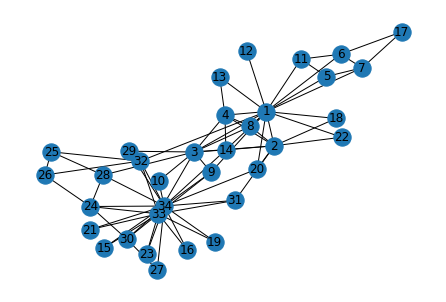

In [22]:
nx.draw(G, with_labels = True)

In [17]:
# Precompute probabilities and generate walks - **ON WINDOWS ONLY WORKS WITH workers=1**
node2vec = Node2Vec(G, dimensions=64, walk_length=30, num_walks=200, workers=4)  # Use temp_folder for big graphs

# Embed nodes
model = node2vec.fit(window=10, min_count=1, batch_words=4)  # Any keywords acceptable by gensim.Word2Vec can be passed, `dimensions` and `workers` are automatically passed (from the Node2Vec constructor)

# Look for most similar nodes
model.wv.most_similar('1')  # Output node names are always strings

Computing transition probabilities:   0%|          | 0/34 [00:00<?, ?it/s]

[('34', 0.9959559440612793),
 ('33', 0.9948056936264038),
 ('3', 0.994347095489502),
 ('2', 0.9941872358322144),
 ('4', 0.9940680265426636),
 ('7', 0.9940451979637146),
 ('32', 0.9938098192214966),
 ('17', 0.9937520027160645),
 ('5', 0.9934478402137756),
 ('11', 0.9902814626693726)]

## Export IMDB Bipartite graph as edgelist

In [33]:
# a map from actor id to a list of movie id's --> actor_movie_adj_list

out = ""
delim = " "

for actor_id, movie_lst in g.actor_movie_adj_list.items():
  for movie_id in movie_lst:
    out += str(actor_id) + delim + str(movie_id) + "\n"

In [38]:
imdb_fn ="data/actor_movie_edgelist"
with open(imdb_fn, "w") as fp:
  fp.write(out)

In [39]:
G_imdb = nx.read_edgelist(imdb_fn, nodetype=int, create_using=nx.DiGraph())
G_imdb = G_imdb.to_undirected()

In [41]:
G_imdb.number_of_nodes()

243377

In [42]:
G_imdb.number_of_edges()

540588

In [ ]:
# Precompute probabilities and generate walks - **ON WINDOWS ONLY WORKS WITH workers=1**
node2vec_imdb = Node2Vec(G_imdb, dimensions=64, walk_length=30, num_walks=200, workers=4)  # Use temp_folder for big graphs

# Embed nodes
model_imdb = node2vec_imdb.fit(window=10, min_count=1, batch_words=4)  # Any keywords acceptable by gensim.Word2Vec can be passed, `dimensions` and `workers` are automatically passed (from the Node2Vec constructor)

Computing transition probabilities:   0%|          | 0/243377 [00:00<?, ?it/s]

In [ ]:
# get actor id for Kevin
actor_name = "Kevin Bacon"
source_id = g.inv_actors_map[actor_name]
print("Actor: {} --> source_id: {}".format(actor_name, source_id))

# Look for most similar nodes
model_imdb.wv.most_similar(str(source_id))  # Output node names are always strings